# Data Visualization with Python (Jupyter Notebook)
## Phân tích trực quan dữ liệu nông nghiệp

### Mục tiêu kinh doanh
Thông qua trực quan hóa dữ liệu, doanh nghiệp hoặc đơn vị quản lý nông nghiệp có thể:

- Xác định **cây trồng, khu vực và mùa vụ** có hiệu quả cao hơn
- Đánh giá ảnh hưởng của **nhiệt độ, lượng mưa, độ ẩm đất và rủi ro nhiệt**
- Hỗ trợ quyết định về **quy hoạch mùa vụ, phân bổ nước tưới, chọn giống và quản trị rủi ro thời tiết**



### Danh sách biểu đồ trong notebook
1. Histogram phân phối năng suất  
2. Boxplot năng suất theo mùa vụ  
3. Boxplot năng suất theo mức độ sẵn có của nước  
4. Bar chart Top 10 cây trồng có năng suất trung bình cao nhất  
5. Bar chart Top 10 khu vực có năng suất trung bình cao nhất  
6. Bar chart năng suất trung bình theo mức độ rủi ro nhiệt  
7. Line chart năng suất trung bình theo mùa vụ và điều kiện nước  
8. Scatter plot nhiệt độ trung bình và năng suất  
9. Scatter plot lượng mưa và năng suất (interactive Plotly)  
10. Heatmap tương quan giữa các biến số quan trọng  
11. Violin plot năng suất theo loại kết cấu đất chiếm ưu thế  
12. Boxplot năng suất của 10 cây trồng xuất hiện nhiều nhất
---

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

candidate_paths = [
    Path("Agri_Data_Cleaned.csv"),
    Path("/mnt/data/Agri_Data_Cleaned.csv")
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Không tìm thấy file Agri_Data_Cleaned.csv")

df = pd.read_csv(data_path)

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Số lượng mùa vụ: {df['Season'].nunique()}")
print(f"Số lượng cây trồng: {df['Crop Name'].nunique()}")
print(f"Số lượng khu vực (District): {df['District'].nunique()}")
display(df.head())

Kích thước dữ liệu: 4,178 dòng x 51 cột
Số lượng mùa vụ: 3
Số lượng cây trồng: 72
Số lượng khu vực (District): 64


,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,...,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield
0,259,Bagerhat,Rabi,17.75,55.0,Wheat,December,Jan To March,April,200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,0.772201
1,421,Bagerhat,Rabi,20.50,60.0,Maize 2,December,Jan To March,April,946.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,2.247031
2,145439,Bagerhat,Rabi,26.00,72.5,Boro,November,Dec To March,April,268754.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,1.847881
3,627,Bagerhat,Rabi,20.50,80.0,Sweet Potato,November,Dec To March,April,2200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,3.508772
4,383,Bagerhat,Kharif 1,31.50,70.0,Mango,April,April To May,April To June,1913.0,...,42.5,2.481885,5.86,22.73,High Risk,1,28.431973,1,0,4.994778


In [2]:
# Kiểm tra nhanh dữ liệu thiếu
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) == 0:
    print("Không có giá trị thiếu trong bộ dữ liệu.")
else:
    display(missing.to_frame("So_luong_thieu"))

Không có giá trị thiếu trong bộ dữ liệu.


## 0) Pie chart — Phân bố số bản ghi theo loại cây trồng và huyện


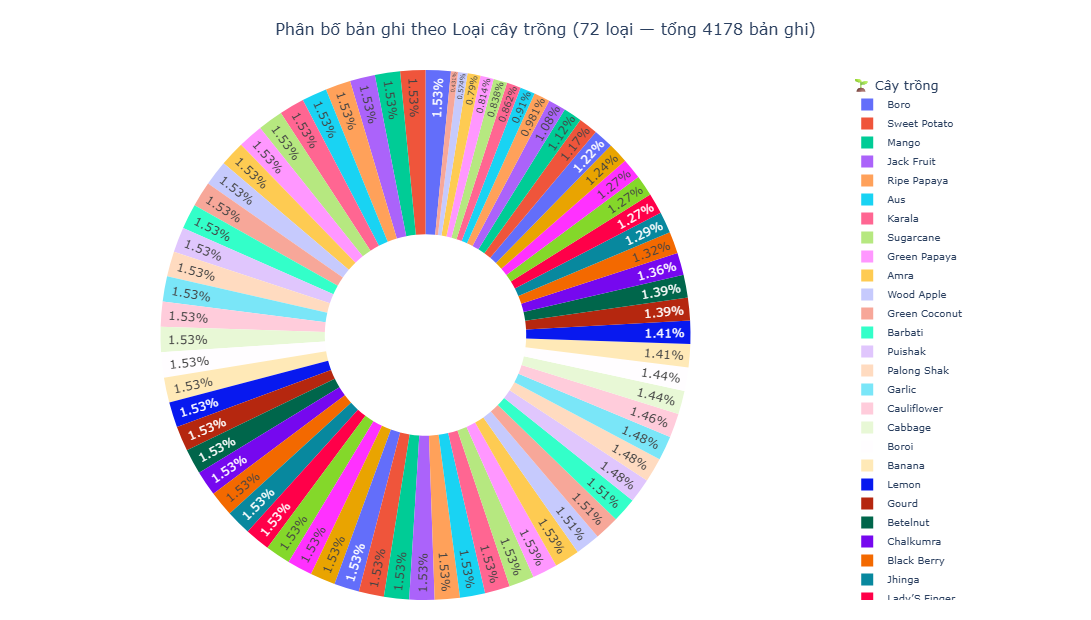

In [3]:
import plotly.graph_objects as go
import pandas as pd

crop_counts = df['Crop Name'].value_counts().reset_index()
crop_counts.columns = ['Crop Name', 'count']

fig_crop = go.Figure(go.Pie(
    labels=crop_counts['Crop Name'],
    values=crop_counts['count'],
    hole=0.38,
    textinfo='percent',
    textposition='inside',
    insidetextorientation='radial',
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Số bản ghi: %{value}<br>'
        'Tỷ lệ: %{percent}<extra></extra>'
    ),
    legendgrouptitle_text='🌱 Cây trồng',
))

fig_crop.update_layout(
    title=dict(
        text=f'Phân bố bản ghi theo Loại cây trồng ({len(crop_counts)} loại — tổng {crop_counts["count"].sum()} bản ghi)',
        font=dict(size=16), x=0.5
    ),
    height=620,
    legend=dict(orientation='v', x=1.02, y=1, font=dict(size=10)),
    template='plotly_white',
    margin=dict(l=20, r=260, t=70, b=20)
)

fig_crop.show()


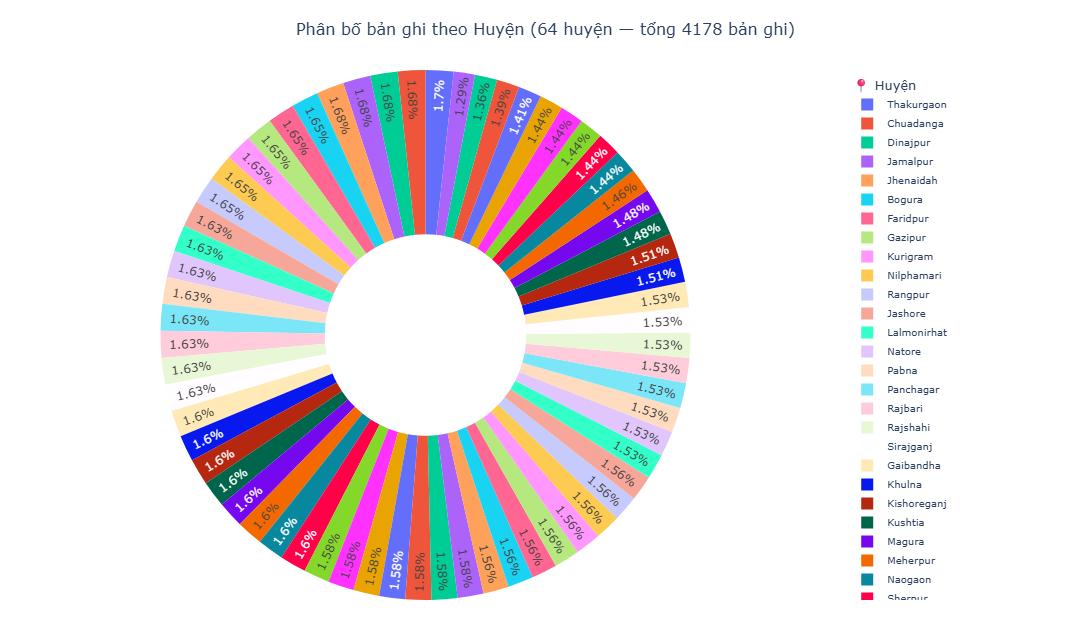

In [4]:
district_counts = df['District'].value_counts().reset_index()
district_counts.columns = ['District', 'count']

fig_district = go.Figure(go.Pie(
    labels=district_counts['District'],
    values=district_counts['count'],
    hole=0.38,
    textinfo='percent',
    textposition='inside',
    insidetextorientation='radial',
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Số bản ghi: %{value}<br>'
        'Tỷ lệ: %{percent}<extra></extra>'
    ),
    legendgrouptitle_text='📍 Huyện',
))

fig_district.update_layout(
    title=dict(
        text=f'Phân bố bản ghi theo Huyện ({len(district_counts)} huyện — tổng {district_counts["count"].sum()} bản ghi)',
        font=dict(size=16), x=0.5
    ),
    height=620,
    legend=dict(orientation='v', x=1.02, y=1, font=dict(size=10)),
    template='plotly_white',
    margin=dict(l=20, r=260, t=70, b=20)
)

fig_district.show()


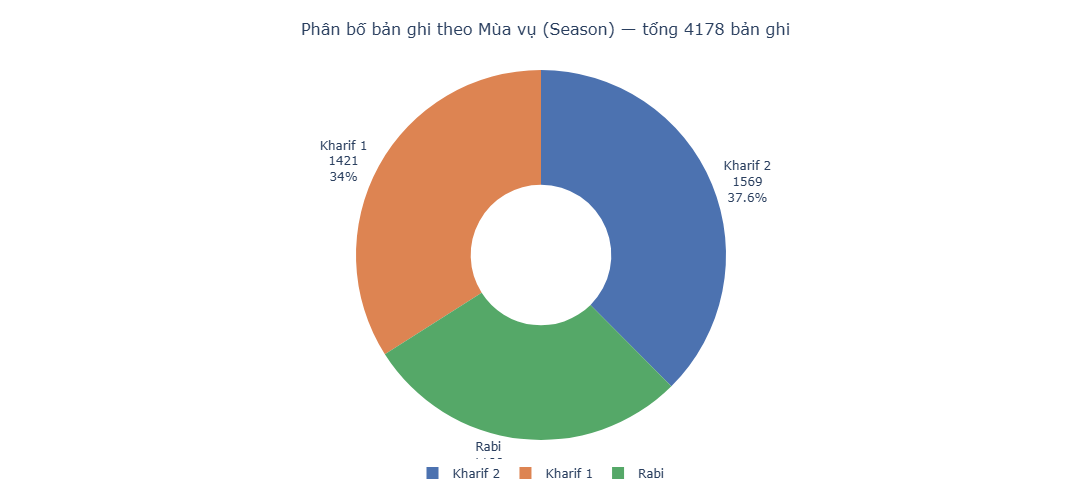

In [5]:
season_counts = df['Season'].value_counts().reset_index()
season_counts.columns = ['Season', 'count']

fig_season = go.Figure(go.Pie(
    labels=season_counts['Season'],
    values=season_counts['count'],
    hole=0.38,
    textinfo='label+percent+value',
    textposition='outside',
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Số bản ghi: %{value}<br>'
        'Tỷ lệ: %{percent}<extra></extra>'
    ),
    marker=dict(colors=['#4C72B0', '#DD8452', '#55A868']),
))

fig_season.update_layout(
    title=dict(
        text=f'Phân bố bản ghi theo Mùa vụ (Season) — tổng {season_counts["count"].sum()} bản ghi',
        font=dict(size=16), x=0.5
    ),
    height=500,
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.05, font=dict(size=12)),
    template='plotly_white',
    margin=dict(l=80, r=80, t=70, b=60)
)

fig_season.show()


**Giải thích:**  
Hai biểu đồ tròn trên cho thấy **cơ cấu phân bố số lượng bản ghi trong bộ dữ liệu** theo hai chiều:
- **Loại cây trồng (trái):** Dữ liệu bao gồm **72 loại cây trồng**. Phần lớn các cây trồng phổ biến (Boro, Sweet Potato, Mango, …) có số bản ghi gần đều nhau (~64 bản ghi/loại), cho thấy bộ dữ liệu được thu thập **khá cân bằng** giữa các cây. Nhóm "Khác" gộp những loại cây ít bản ghi hơn (Tobacco, Cheena, …).
- **Huyện (phải):** Dữ liệu trải rộng trên **64 huyện**. Các huyện như Thakurgaon, Dinajpur, Jamalpur có số bản ghi cao hơn một chút, trong khi Habiganj, Coxsbazar có ít hơn, phản ánh sự khác biệt nhỏ về phạm vi thu thập dữ liệu theo địa bàn.

Về mặt kinh doanh, biểu đồ này giúp đánh giá **mức độ đại diện của dữ liệu**: nếu một loại cây hoặc một huyện có quá ít bản ghi, các phân tích và dự báo cho đối tượng đó sẽ kém tin cậy hơn và cần được bổ sung thêm dữ liệu trước khi ra quyết định.


## 1) Histogram — Phân phối năng suất (Yield)

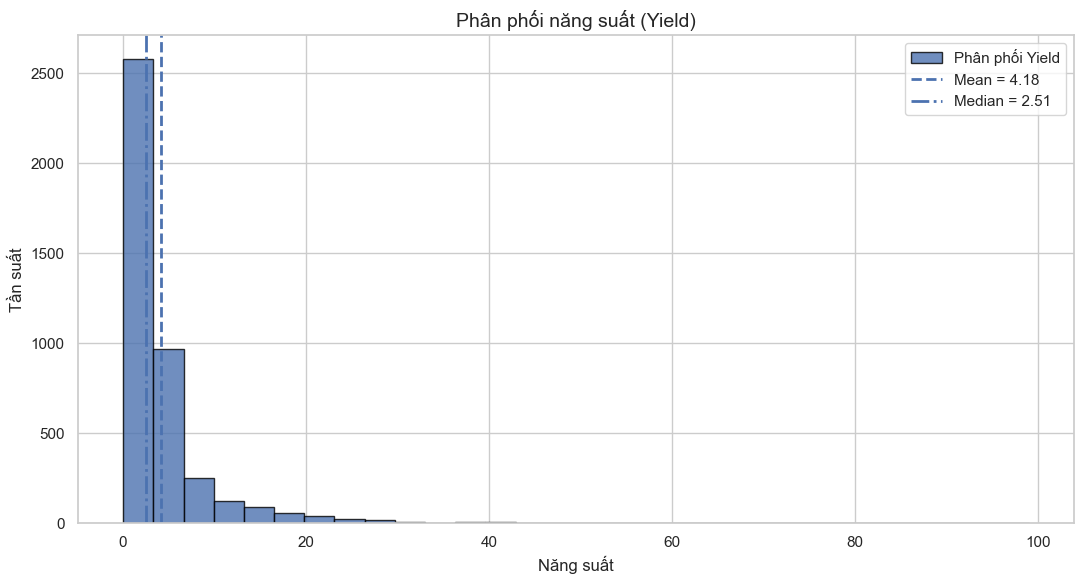

In [6]:
yield_mean = df["Yield"].mean()
yield_median = df["Yield"].median()

plt.figure(figsize=(11, 6))
plt.hist(df["Yield"], bins=30, edgecolor="black", alpha=0.8, label="Phân phối Yield")
plt.axvline(yield_mean, linestyle="--", linewidth=2, label=f"Mean = {yield_mean:.2f}")
plt.axvline(yield_median, linestyle="-.", linewidth=2, label=f"Median = {yield_median:.2f}")

plt.title("Phân phối năng suất (Yield)")
plt.xlabel("Năng suất")
plt.ylabel("Tần suất")
plt.legend()
plt.tight_layout()
plt.show()

**Giải thích:**  
Biểu đồ histogram cho thấy **cách các giá trị năng suất phân bố trong toàn bộ bộ dữ liệu**. Việc bổ sung đường trung bình và trung vị giúp đánh giá xem phân phối có bị lệch hay không. Đây là biểu đồ nền tảng vì trước khi đi sâu vào phân tích theo mùa vụ, cây trồng hay điều kiện thời tiết, ta cần biết năng suất thường tập trung ở vùng nào và có xuất hiện giá trị ngoại lệ hay không.  
Về mặt kinh doanh, biểu đồ này hỗ trợ việc xác định **mức năng suất điển hình**, nhận diện tình huống sản xuất bất thường và chuẩn bị cho các bước phân tích nâng cao như dự báo hoặc phân khúc hiệu quả canh tác.

## 2) Boxplot — So sánh năng suất theo mùa vụ

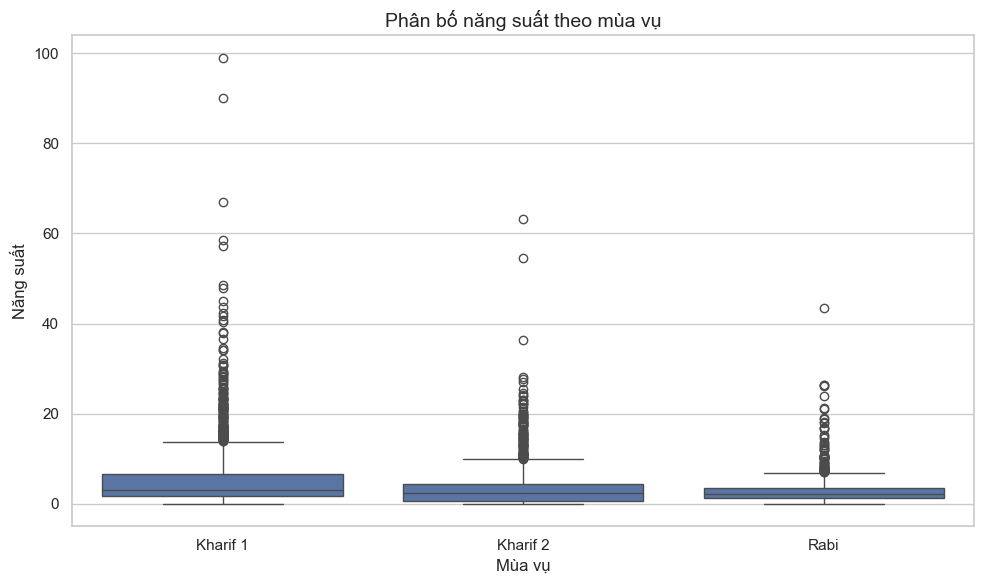

In [7]:
season_order = ["Kharif 1", "Kharif 2", "Rabi"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Season", y="Yield", order=season_order)

plt.title("Phân bố năng suất theo mùa vụ")
plt.xlabel("Mùa vụ")
plt.ylabel("Năng suất")
plt.tight_layout()
plt.show()

**Giải thích:**  
Boxplot cho thấy **mức trung vị, độ phân tán và các điểm ngoại lệ của năng suất theo từng mùa vụ**. Không chỉ nhìn vào giá trị trung bình, biểu đồ này còn cho thấy mùa vụ nào ổn định hơn và mùa vụ nào biến động mạnh hơn.  
Trong bài toán kinh doanh, điều này rất quan trọng vì doanh nghiệp không chỉ quan tâm đến mức năng suất cao, mà còn quan tâm đến **độ ổn định của sản lượng**. Một mùa vụ có năng suất trung bình tốt nhưng biến động quá lớn có thể mang lại rủi ro cao trong lập kế hoạch sản xuất và phân bổ nguồn lực.

## 3) Boxplot — So sánh năng suất theo mức độ sẵn có của nước

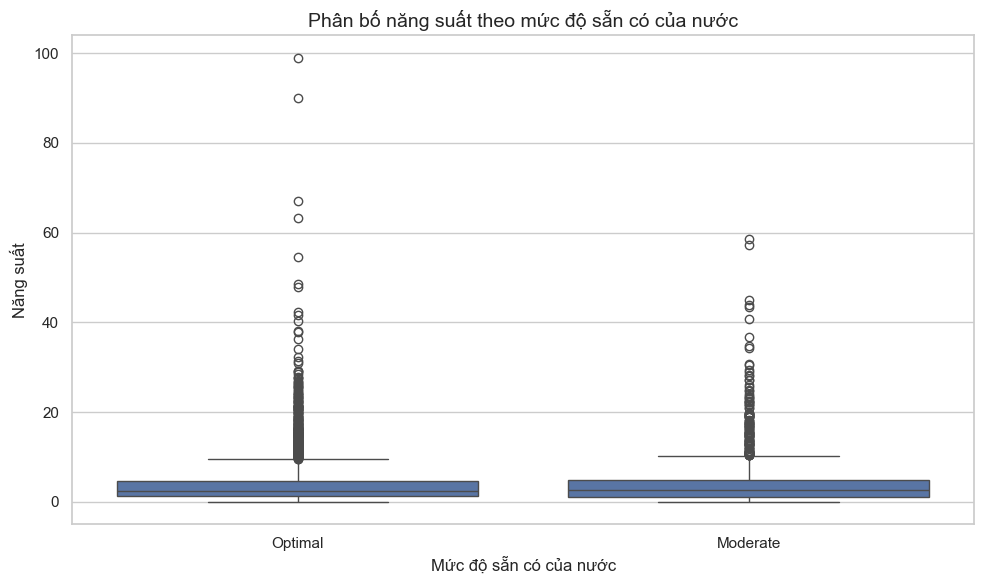

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Water_Availability_Cat", y="Yield")

plt.title("Phân bố năng suất theo mức độ sẵn có của nước")
plt.xlabel("Mức độ sẵn có của nước")
plt.ylabel("Năng suất")
plt.tight_layout()
plt.show()

**Giải thích:**  
Biểu đồ cho thấy sự khác biệt về **phân bố năng suất giữa các nhóm điều kiện nước**. Đây là một góc nhìn rất quan trọng trong nông nghiệp vì nước là một yếu tố đầu vào có ảnh hưởng trực tiếp đến tăng trưởng cây trồng và rủi ro mất mùa.  
Liên hệ với bài toán kinh doanh, biểu đồ giúp trả lời câu hỏi: **đầu tư vào quản lý nước và thủy lợi có đáng giá hay không?** Nếu nhóm có điều kiện nước tốt hơn có phân bố năng suất cao và ổn định hơn, đây là cơ sở mạnh để ưu tiên đầu tư vào hạ tầng hoặc chính sách tưới tiêu.

## 4) Bar chart — Top 10 cây trồng có năng suất trung bình cao nhất

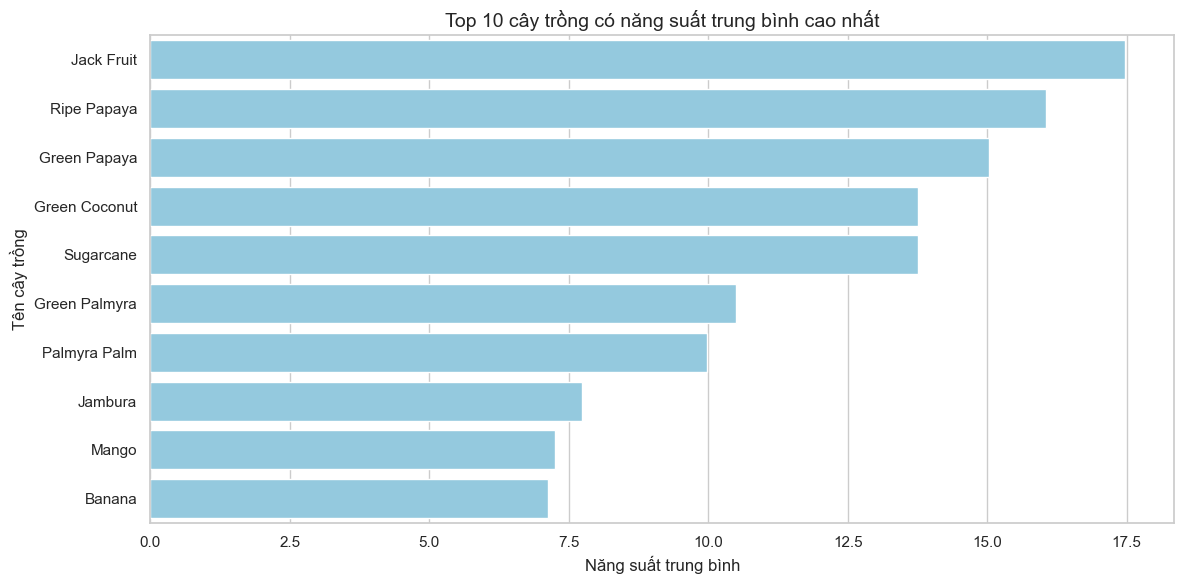

In [9]:
top10_crop_yield = (
    df.groupby("Crop Name", as_index=False)["Yield"]
      .mean()
      .sort_values("Yield", ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_crop_yield, x="Yield", y="Crop Name", color="skyblue")

plt.title("Top 10 cây trồng có năng suất trung bình cao nhất")
plt.xlabel("Năng suất trung bình")
plt.ylabel("Tên cây trồng")
plt.tight_layout()
plt.show()

**Giải thích:**  
Biểu đồ cột này giúp xác định **những loại cây trồng đạt năng suất trung bình cao nhất** trong dữ liệu. Đây là một trong những biểu đồ quan trọng nhất vì nó trả lời trực tiếp câu hỏi kinh doanh: **nên ưu tiên loại cây nào để tối ưu sản lượng?**  
Từ góc độ chiến lược, kết quả này có thể hỗ trợ việc lựa chọn danh mục cây trồng, phân bổ ngân sách đầu vào, định hướng vùng trồng và xây dựng kế hoạch canh tác theo hiệu quả thực tế.

## 5) Bar chart — Top 10 khu vực có năng suất trung bình cao nhất

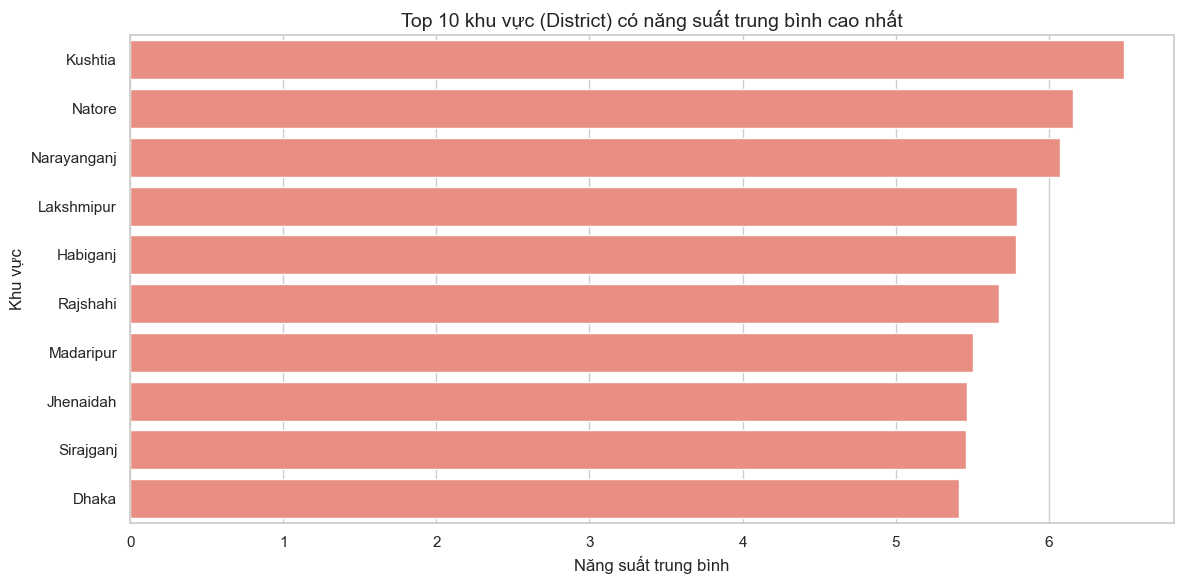

In [10]:
top10_district_yield = (
    df.groupby("District", as_index=False)["Yield"]
      .mean()
      .sort_values("Yield", ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_district_yield, x="Yield", y="District", color="salmon")

plt.title("Top 10 khu vực (District) có năng suất trung bình cao nhất")
plt.xlabel("Năng suất trung bình")
plt.ylabel("Khu vực")
plt.tight_layout()
plt.show()

**Giải thích:**  
Biểu đồ cho thấy **10 khu vực có năng suất trung bình cao nhất**. Đây là góc nhìn quan trọng để so sánh hiệu quả sản xuất theo địa bàn và nhận diện các khu vực có điều kiện canh tác thuận lợi hơn.  
Trong bài toán kinh doanh, biểu đồ hỗ trợ việc đưa ra quyết định về **mở rộng vùng sản xuất, học hỏi mô hình canh tác từ khu vực hiệu quả cao** hoặc phân tích sâu hơn nguyên nhân tạo ra khác biệt giữa các địa phương.

## 6) Bar chart — Năng suất trung bình theo mức độ rủi ro nhiệt

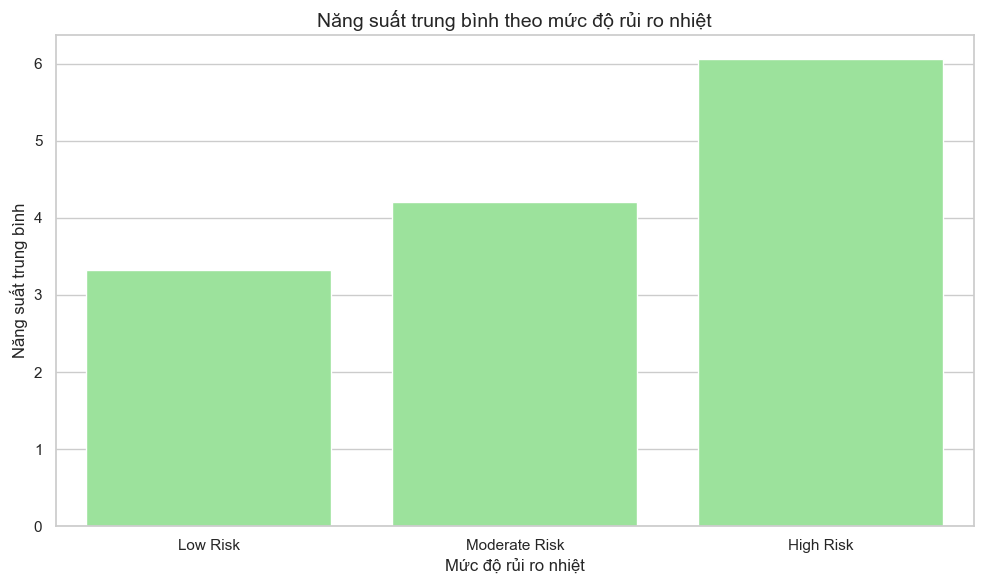

In [11]:
heat_risk_order = ["Low Risk", "Moderate Risk", "High Risk"]

heat_risk_yield = (
    df.groupby("Extreme_Heat_Risk", as_index=False)["Yield"]
      .mean()
)

heat_risk_yield["Extreme_Heat_Risk"] = pd.Categorical(
    heat_risk_yield["Extreme_Heat_Risk"],
    categories=heat_risk_order,
    ordered=True
)
heat_risk_yield = heat_risk_yield.sort_values("Extreme_Heat_Risk")

plt.figure(figsize=(10, 6))
sns.barplot(data=heat_risk_yield, x="Extreme_Heat_Risk", y="Yield", color="lightgreen")

plt.title("Năng suất trung bình theo mức độ rủi ro nhiệt")
plt.xlabel("Mức độ rủi ro nhiệt")
plt.ylabel("Năng suất trung bình")
plt.tight_layout()
plt.show()

**Giải thích:**  
Biểu đồ thể hiện sự khác biệt về **năng suất trung bình giữa các mức độ rủi ro nhiệt**. Đây là một cách trực quan để đánh giá tác động của điều kiện nhiệt cực đoan lên kết quả sản xuất.  
Về mặt kinh doanh, biểu đồ này liên quan trực tiếp đến bài toán **quản trị rủi ro khí hậu**. Nếu các nhóm có rủi ro nhiệt cao cho năng suất thấp hơn hoặc bất ổn hơn, doanh nghiệp có thể cân nhắc thay đổi lịch mùa vụ, chọn giống chịu nhiệt hoặc đầu tư vào biện pháp giảm sốc nhiệt.

## 7) Line chart — Năng suất trung bình theo mùa vụ và điều kiện nước (Plotly)

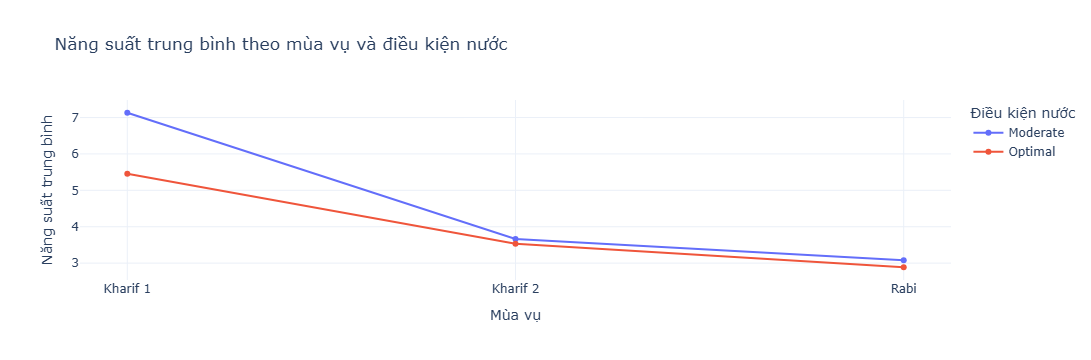

In [12]:
season_water_yield = (
    df.groupby(["Season", "Water_Availability_Cat"], as_index=False)["Yield"]
      .mean()
)

season_water_yield["Season"] = pd.Categorical(
    season_water_yield["Season"],
    categories=season_order,
    ordered=True
)
season_water_yield = season_water_yield.sort_values("Season")

fig = px.line(
    season_water_yield,
    x="Season",
    y="Yield",
    color="Water_Availability_Cat",
    markers=True,
    title="Năng suất trung bình theo mùa vụ và điều kiện nước",
    labels={
        "Season": "Mùa vụ",
        "Yield": "Năng suất trung bình",
        "Water_Availability_Cat": "Điều kiện nước"
    }
)

fig.update_layout(
    legend_title_text="Điều kiện nước",
    template="plotly_white"
)
fig.show()

**Giải thích:**  
Biểu đồ đường cho thấy **năng suất thay đổi theo mùa vụ**, đồng thời cho phép so sánh giữa các nhóm điều kiện nước. Đây là biểu đồ hữu ích vì nó không chỉ xem từng yếu tố riêng lẻ mà còn thể hiện **tương tác giữa mùa vụ và nguồn nước**.  
Trong bối cảnh kinh doanh, biểu đồ này giúp xác định **mùa vụ nào tận dụng điều kiện nước tốt hơn**, từ đó phục vụ việc lập kế hoạch gieo trồng, phân phối nước tưới và đánh giá hiệu quả đầu tư vào hạ tầng nước theo từng mùa.

## 8) Scatter plot — Mối quan hệ giữa nhiệt độ trung bình và năng suất

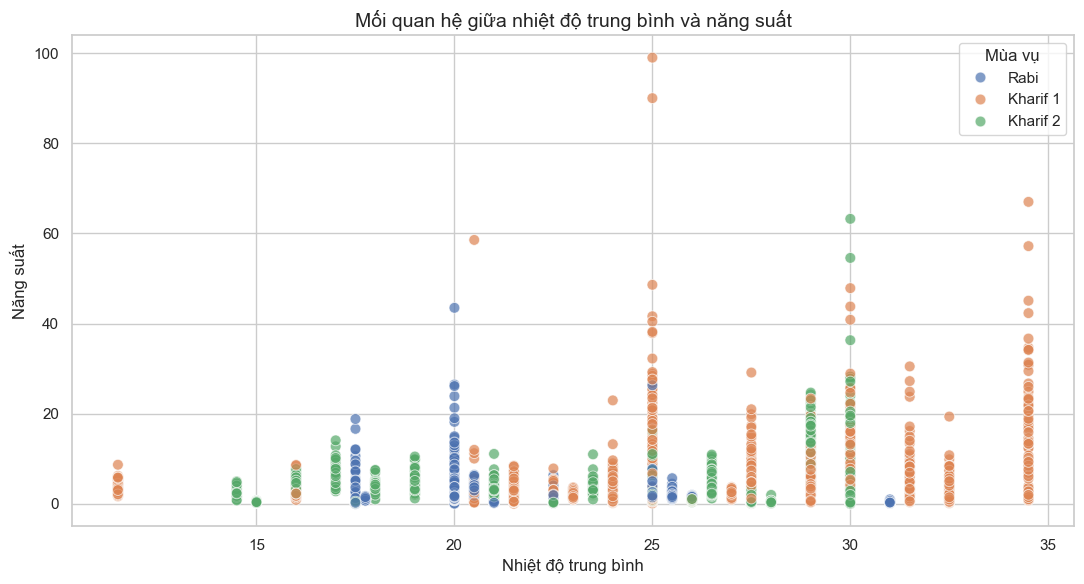

In [13]:
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x="Avg Temp",
    y="Yield",
    hue="Season",
    alpha=0.7,
    s=60
)

plt.title("Mối quan hệ giữa nhiệt độ trung bình và năng suất")
plt.xlabel("Nhiệt độ trung bình")
plt.ylabel("Năng suất")
plt.legend(title="Mùa vụ")
plt.tight_layout()
plt.show()

**Giải thích:**  
Biểu đồ phân tán này giúp quan sát xem **năng suất có xu hướng thay đổi như thế nào khi nhiệt độ trung bình thay đổi**, đồng thời cho phép so sánh giữa các mùa vụ.  
Điều này quan trọng vì nhiệt độ là một biến khí hậu nền tảng ảnh hưởng mạnh đến sinh trưởng cây trồng. Về mặt kinh doanh, biểu đồ này cung cấp cơ sở để đánh giá **ngưỡng nhiệt độ thuận lợi**, hỗ trợ chọn mùa vụ phù hợp và xây dựng chiến lược canh tác thích ứng với biến đổi khí hậu.

## 9) Scatter plot — Mối quan hệ giữa lượng mưa và năng suất (Plotly interactive)

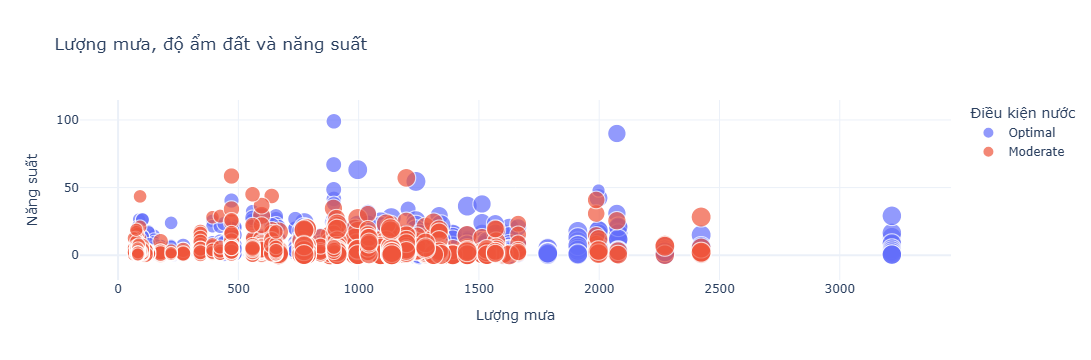

In [14]:
fig = px.scatter(
    df,
    x="Rainfall",
    y="Yield",
    color="Water_Availability_Cat",
    size="Soil_Moisture_mm",
    hover_data=["Crop Name", "District", "Season"],
    title="Lượng mưa, độ ẩm đất và năng suất",
    labels={
        "Rainfall": "Lượng mưa",
        "Yield": "Năng suất",
        "Water_Availability_Cat": "Điều kiện nước",
        "Soil_Moisture_mm": "Độ ẩm đất"
    }
)

fig.update_layout(
    legend_title_text="Điều kiện nước",
    template="plotly_white"
)
fig.show()

**Giải thích:**  
Biểu đồ interactive này kết hợp **lượng mưa, độ ẩm đất và năng suất** trên cùng một hình, giúp người xem nhìn sâu hơn vào mối quan hệ giữa yếu tố khí hậu và điều kiện nước trong đất. Kích thước điểm phản ánh độ ẩm đất, còn màu sắc thể hiện nhóm điều kiện nước.  
Trong bài toán kinh doanh, biểu đồ này đặc biệt hữu ích vì nó hỗ trợ phân tích đa chiều: **không phải cứ mưa nhiều là năng suất cao**, mà cần xem thêm khả năng giữ ẩm và điều kiện nước thực tế. Đây là đầu vào tốt cho quyết định đầu tư tưới tiêu, cảnh báo khô hạn hoặc đánh giá hiệu quả điều tiết nước.

## 10) Heatmap — Tương quan giữa các biến số quan trọng và năng suất

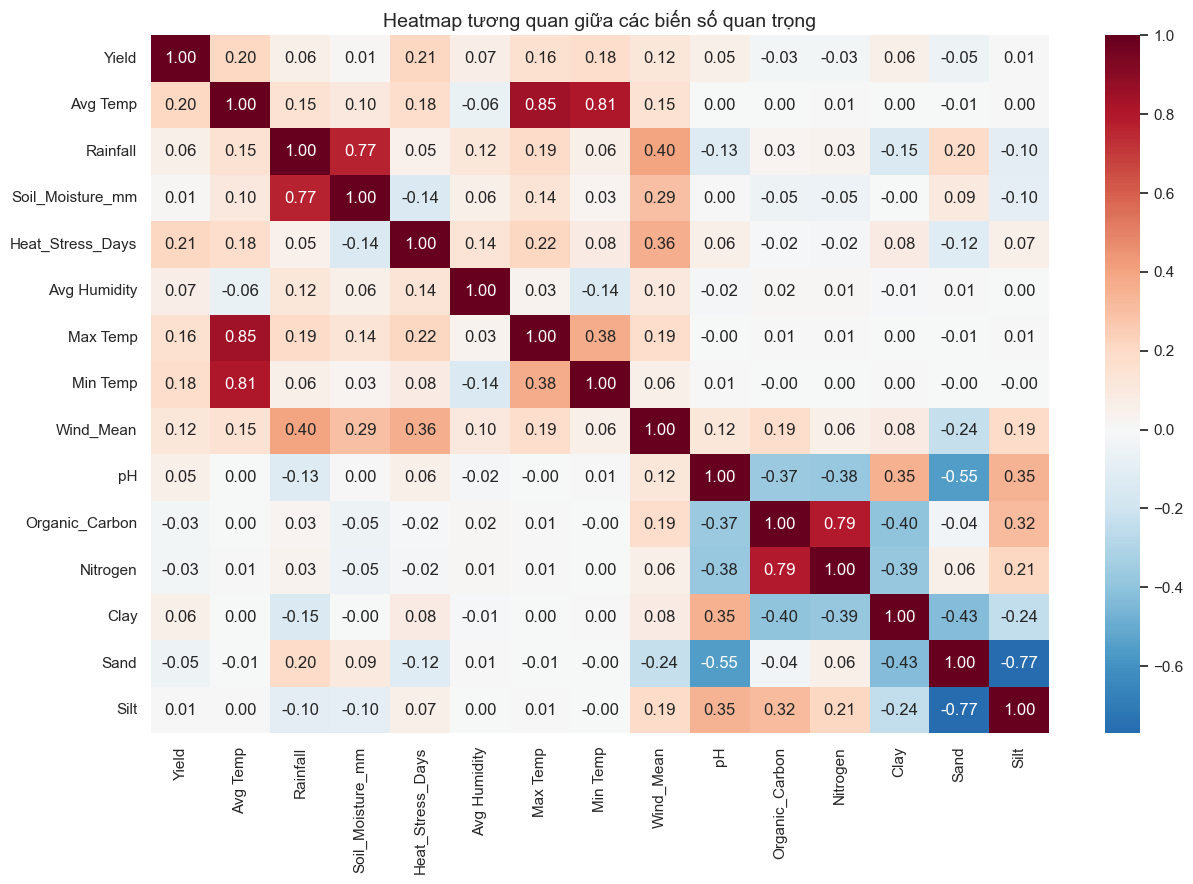

In [15]:
selected_cols = [
    "Yield", "Avg Temp", "Rainfall", "Soil_Moisture_mm", "Heat_Stress_Days",
    "Avg Humidity", "Max Temp", "Min Temp", "Wind_Mean", "pH",
    "Organic_Carbon", "Nitrogen", "Clay", "Sand", "Silt"
]

corr_matrix = df[selected_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)

plt.title("Heatmap tương quan giữa các biến số quan trọng")
plt.tight_layout()
plt.show()

**Giải thích:**  
Heatmap cho thấy **mức độ tương quan tuyến tính giữa các biến số quan trọng** như nhiệt độ, lượng mưa, độ ẩm đất, dinh dưỡng đất và năng suất. Đây là biểu đồ rất hữu ích ở giai đoạn khám phá dữ liệu vì nó giúp nhanh chóng xác định biến nào có khả năng liên quan mạnh hơn đến `Yield`.  
Trong bối cảnh kinh doanh, biểu đồ này hỗ trợ việc ưu tiên các yếu tố cần theo dõi hoặc đầu tư. Ví dụ, nếu một nhóm biến khí hậu hoặc đất có tương quan đáng chú ý với năng suất, doanh nghiệp có thể tập trung vào việc đo lường, kiểm soát hoặc mô hình hóa các yếu tố đó trong hệ thống ra quyết định.

## 11) Violin plot — Năng suất theo loại kết cấu đất chiếm ưu thế

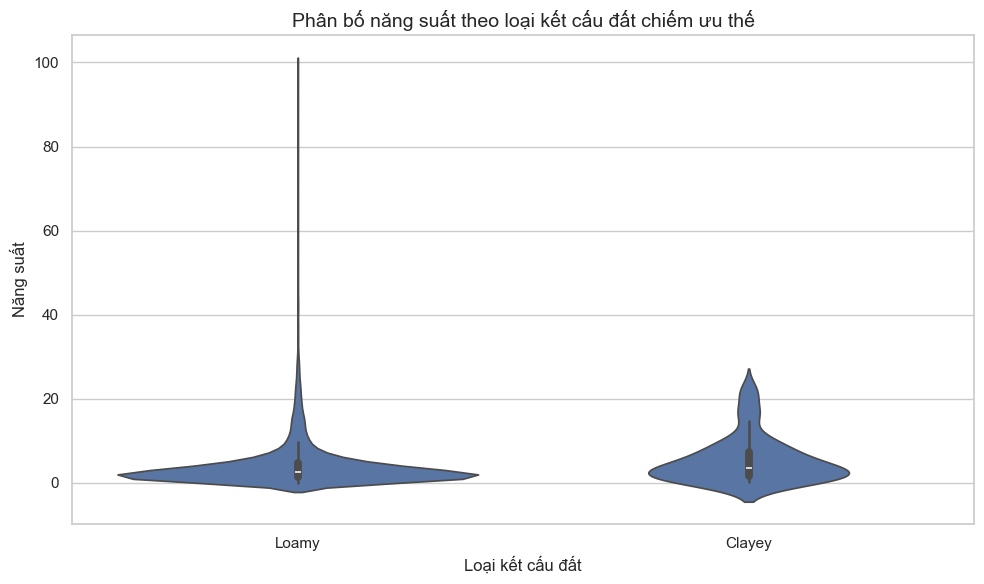

In [16]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Dominant_Soil_Texture", y="Yield", inner="box")

plt.title("Phân bố năng suất theo loại kết cấu đất chiếm ưu thế")
plt.xlabel("Loại kết cấu đất")
plt.ylabel("Năng suất")
plt.tight_layout()
plt.show()

**Giải thích:**  
Violin plot cho thấy không chỉ trung vị và độ phân tán, mà còn thể hiện **hình dạng phân phối năng suất theo từng loại đất**. Đây là biểu đồ phù hợp khi muốn so sánh xem loại đất nào có xu hướng tạo ra mức năng suất tập trung cao hơn hoặc biến động rộng hơn.  
Liên hệ đến bài toán kinh doanh, biểu đồ này giúp đánh giá vai trò của **đặc tính đất** trong hiệu quả sản xuất. Điều này hỗ trợ quy hoạch cây trồng phù hợp theo vùng đất và định hướng các biện pháp cải tạo đất nếu cần.

## 12) Boxplot — Năng suất của 10 cây trồng xuất hiện nhiều nhất

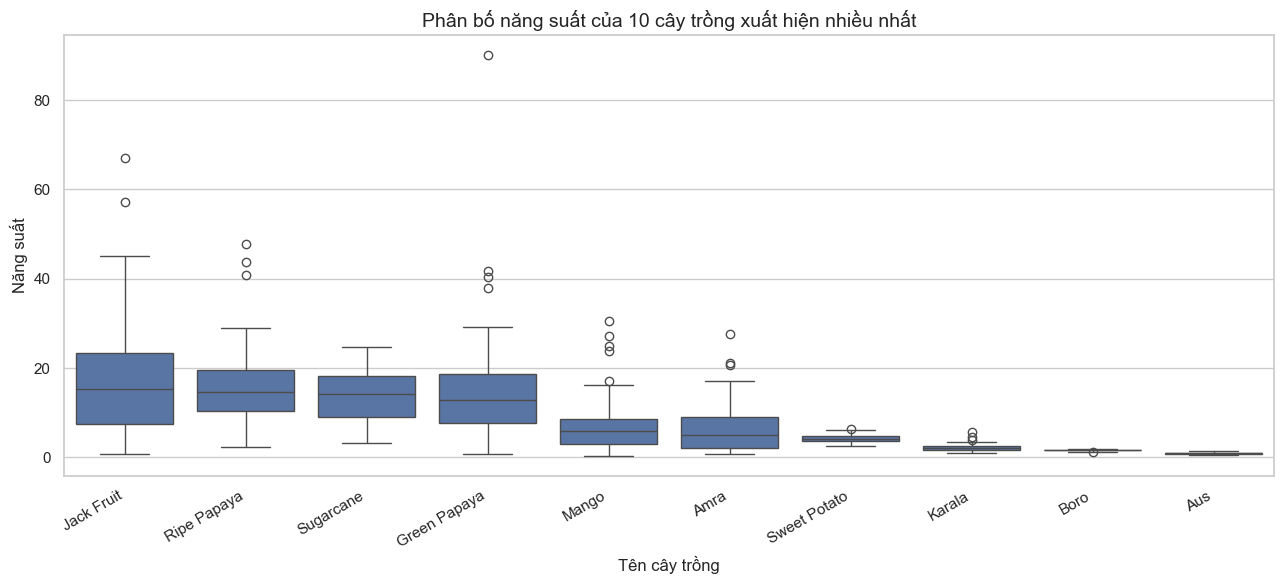

In [17]:
top10_freq_crops = df["Crop Name"].value_counts().head(10).index.tolist()
df_top_crops = df[df["Crop Name"].isin(top10_freq_crops)].copy()

median_order = (
    df_top_crops.groupby("Crop Name")["Yield"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(13, 6))
sns.boxplot(data=df_top_crops, x="Crop Name", y="Yield", order=median_order)

plt.title("Phân bố năng suất của 10 cây trồng xuất hiện nhiều nhất")
plt.xlabel("Tên cây trồng")
plt.ylabel("Năng suất")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Giải thích:**  
Biểu đồ này tập trung vào **10 cây trồng xuất hiện nhiều nhất trong dữ liệu**, từ đó giúp so sánh phân bố năng suất của các cây trồng phổ biến thay vì chỉ nhìn vào nhóm có năng suất trung bình cao nhất.  
Đây là góc nhìn rất thực tế cho bài toán kinh doanh vì những cây trồng phổ biến thường là nhóm đang được sản xuất rộng rãi. So sánh mức trung vị, độ phân tán và ngoại lệ giữa các cây này giúp đánh giá **cây nào vừa phổ biến vừa hiệu quả**, từ đó hỗ trợ quyết định duy trì, mở rộng hay tối ưu quy trình canh tác.

## Kết luận và liên hệ bài toán kinh doanh

Từ các biểu đồ trên, có thể rút ra một số hướng phân tích và ra quyết định:

1. **Danh mục cây trồng:** Xác định cây trồng có năng suất cao và cây trồng phổ biến nhưng chưa tối ưu để ưu tiên cải thiện.
2. **Hiệu quả theo mùa vụ:** So sánh mùa vụ để lựa chọn lịch canh tác phù hợp hơn.
3. **Quản lý nước:** Đánh giá mức độ ảnh hưởng của điều kiện nước, lượng mưa và độ ẩm đất đến năng suất.
4. **Quản trị rủi ro khí hậu:** Theo dõi vai trò của nhiệt độ và rủi ro nhiệt trong việc làm thay đổi năng suất.
5. **Quy hoạch theo khu vực và đất đai:** Tìm ra các địa bàn và loại đất phù hợp để mở rộng hoặc tối ưu sản xuất.
